In [10]:
# Setup main working directory
import os 
working_dir = "/mnt/h/Projects/scRNA-Seq/RetinoblastomaAtlas/"
os.makedirs(working_dir, exist_ok=True)
os.chdir(working_dir)

In [13]:
# Set Save paths for easy use later
raw_data_dir = os.path.join(working_dir, "data/raw")
processed_data_dir = os.path.join(working_dir, "data/processed")
results_dir = os.path.join(working_dir, "results")
figures_dir = os.path.join(working_dir, "results/figures")
tables_dir = os.path.join(working_dir, "results/tables")

In [15]:
import tarfile

# Define the datasets to extract
datasets = ["GSE168434", "GSE249995"]

for accession in datasets:
    # Define paths
    tar_path = os.path.join(raw_data_dir, f"{accession}_RAW.tar")
    extract_dir = os.path.join(raw_data_dir, accession)

    # Create specific directory
    os.makedirs(extract_dir, exist_ok=True)

    print(f"Extracting {tar_path} to {extract_dir}...")

    # Extract tar file
    try:
        with tarfile.open(tar_path, "r") as tar:
            tar.extractall(path=extract_dir)
        print(f"Successfully extracted {accession}.")
    except Exception as e:
        print(f"Error extracting {accession}: {e}")

Extracting /mnt/h/Projects/scRNA-Seq/RetinoblastomaAtlas/data/raw/GSE168434_RAW.tar to /mnt/h/Projects/scRNA-Seq/RetinoblastomaAtlas/data/raw/GSE168434...


/tmp/ipykernel_2202/3075527057.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Successfully extracted GSE168434.
Extracting /mnt/h/Projects/scRNA-Seq/RetinoblastomaAtlas/data/raw/GSE249995_RAW.tar to /mnt/h/Projects/scRNA-Seq/RetinoblastomaAtlas/data/raw/GSE249995...
Successfully extracted GSE249995.


In [16]:
# Extract nested tar.gz files in GSE168434
gse168434_dir = os.path.join(raw_data_dir, "GSE168434")

for filename in os.listdir(gse168434_dir):
    if filename.endswith(".tar.gz"):
        sample_name = filename.split('_counts')[0] # Extract sample ID
        sample_dir = os.path.join(gse168434_dir, sample_name)
        os.makedirs(sample_dir, exist_ok=True)

        file_path = os.path.join(gse168434_dir, filename)
        print(f"Extracting {filename}...")

        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=sample_dir)

print("Extraction of GSE168434 sub-files complete.")

Extracting GSM5139852_RB01_rep1_counts.mtx.tsv.tar.gz...


/tmp/ipykernel_2202/1127286403.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=sample_dir)


Extracting GSM5139853_RB01_rep2_counts.mtx.tsv.tar.gz...
Extracting GSM5139854_RB02_rep1_counts.mtx.tsv.tar.gz...
Extracting GSM5139855_RB02_rep2_counts.mtx.tsv.tar.gz...
Extracting GSM5139856_RB03_rep1_counts.mtx.tsv.tar.gz...
Extracting GSM5139857_RB03_rep2_counts.mtx.tsv.tar.gz...
Extracting GSM5139858_RB04_counts.mtx.tsv.tar.gz...
Extracting GSM5139859_RB05_counts.mtx.tsv.tar.gz...
Extracting GSM5139860_RB06_counts.mtx.tsv.tar.gz...
Extracting GSM5139861_RB07_counts.mtx.tsv.tar.gz...
Extraction of GSE168434 sub-files complete.


In [20]:
# Final verification of the raw_data directory structure
list_files(raw_data_dir)

raw/
    GSE168434_RAW.tar
    GSE249995_RAW.tar
    GSE168434/
        GSM5139852_RB01_rep1_counts.mtx.tsv.tar.gz
        GSM5139853_RB01_rep2_counts.mtx.tsv.tar.gz
        GSM5139854_RB02_rep1_counts.mtx.tsv.tar.gz
        GSM5139855_RB02_rep2_counts.mtx.tsv.tar.gz
        GSM5139856_RB03_rep1_counts.mtx.tsv.tar.gz
        GSM5139857_RB03_rep2_counts.mtx.tsv.tar.gz
        GSM5139858_RB04_counts.mtx.tsv.tar.gz
        GSM5139859_RB05_counts.mtx.tsv.tar.gz
        GSM5139860_RB06_counts.mtx.tsv.tar.gz
        GSM5139861_RB07_counts.mtx.tsv.tar.gz
        GSM5139852_RB01_rep1/
            barcodes.tsv.gz
            features.tsv.gz
            matrix.mtx.gz
            home/
                wucheng/
                    Aspera/
                        RB_raw/
                            RB01_rep1_filtered_feature_bc_matrix/
                                barcodes.tsv.gz
                                features.tsv.gz
                                matrix.mtx.gz
        GSM5139853_RB01

In [18]:
import shutil

# Flatten GSE168434 directory structure
for sample_id in os.listdir(gse168434_dir):
    sample_path = os.path.join(gse168434_dir, sample_id)
    if os.path.isdir(sample_path):
        # Look for the matrix files deep in the extracted paths
        for root, dirs, files in os.walk(sample_path):
            if "matrix.mtx.gz" in files:
                for f in files:
                    src = os.path.join(root, f)
                    dst = os.path.join(sample_path, f)
                    shutil.move(src, dst)
                break # Found the files, move to next sample

        # Remove the now empty 'home' directory structure
        home_dir = os.path.join(sample_path, "home")
        if os.path.exists(home_dir):
            shutil.rmtree(home_dir)

print("GSE168434 structure flattened and cleaned.")
list_files(gse168434_dir)

GSE168434 structure flattened and cleaned.
GSE168434/
    GSM5139852_RB01_rep1_counts.mtx.tsv.tar.gz
    GSM5139853_RB01_rep2_counts.mtx.tsv.tar.gz
    GSM5139854_RB02_rep1_counts.mtx.tsv.tar.gz
    GSM5139855_RB02_rep2_counts.mtx.tsv.tar.gz
    GSM5139856_RB03_rep1_counts.mtx.tsv.tar.gz
    GSM5139857_RB03_rep2_counts.mtx.tsv.tar.gz
    GSM5139858_RB04_counts.mtx.tsv.tar.gz
    GSM5139859_RB05_counts.mtx.tsv.tar.gz
    GSM5139860_RB06_counts.mtx.tsv.tar.gz
    GSM5139861_RB07_counts.mtx.tsv.tar.gz
    GSM5139852_RB01_rep1/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    GSM5139853_RB01_rep2/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    GSM5139854_RB02_rep1/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    GSM5139855_RB02_rep2/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    GSM5139856_RB03_rep1/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    GSM5139857_R

In [21]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

In [22]:
# 1. Loading GSE168434
adatas_168434 = []
gse168434_dir = os.path.join(raw_data_dir, 'GSE168434')
samples_168434 = [d for d in os.listdir(gse168434_dir) if os.path.isdir(os.path.join(gse168434_dir, d))]

for sample in sorted(samples_168434):
    sample_path = os.path.join(gse168434_dir, sample)
    print(f'Loading GSE168434 sample: {sample}...')
    adata_s = sc.read_10x_mtx(sample_path, var_names='gene_symbols', cache=False)
    adata_s.var_names_make_unique()
    adata_s.obs['sample_id'] = sample
    adata_s.obs['dataset'] = 'GSE168434'
    adatas_168434.append(adata_s)

# 2. Loading GSE249995
gse249995_dir = os.path.join(raw_data_dir, 'GSE249995')
adatas_249995 = []
gsm_prefixes = sorted(list(set([f.split('_')[0] for f in os.listdir(gse249995_dir) if f.startswith('GSM')])))

for gsm in gsm_prefixes:
    print(f'Loading GSE249995 sample: {gsm}...')
    mtx_file = [f for f in os.listdir(gse249995_dir) if f.startswith(gsm) and 'matrix.mtx' in f][0]
    features_file = [f for f in os.listdir(gse249995_dir) if f.startswith(gsm) and 'features.tsv' in f][0]
    barcodes_file = [f for f in os.listdir(gse249995_dir) if f.startswith(gsm) and 'barcodes.tsv' in f][0]

    adata_s = sc.read_mtx(os.path.join(gse249995_dir, mtx_file)).T
    genes = pd.read_csv(os.path.join(gse249995_dir, features_file), header=None, sep='\t')
    barcodes = pd.read_csv(os.path.join(gse249995_dir, barcodes_file), header=None, sep='\t')

    adata_s.var_names = genes[1].values
    adata_s.var_names_make_unique()
    adata_s.var['gene_ids'] = genes[0].values
    adata_s.obs_names = barcodes[0].values
    adata_s.obs['sample_id'] = gsm
    adata_s.obs['dataset'] = 'GSE249995'
    adatas_249995.append(adata_s)

# Combine all using outer join to preserve all genes across studies
adata = ad.concat(adatas_168434 + adatas_249995, label='batch', join='outer', index_unique='-')
adata.obs_names_make_unique()

# Save the raw merged data
save_path = os.path.join(processed_data_dir, "merged_raw_atlas.h5ad")
adata.write(save_path)
print(f'\nMerged AnnData object created and saved to: {save_path}')
print(adata)

Loading GSE168434 sample: GSM5139852_RB01_rep1...
Loading GSE168434 sample: GSM5139853_RB01_rep2...
Loading GSE168434 sample: GSM5139854_RB02_rep1...
Loading GSE168434 sample: GSM5139855_RB02_rep2...
Loading GSE168434 sample: GSM5139856_RB03_rep1...
Loading GSE168434 sample: GSM5139857_RB03_rep2...
Loading GSE168434 sample: GSM5139858_RB04...
Loading GSE168434 sample: GSM5139859_RB05...
Loading GSE168434 sample: GSM5139860_RB06...
Loading GSE168434 sample: GSM5139861_RB07...
Loading GSE249995 sample: GSM7968797...
Loading GSE249995 sample: GSM7968798...


/tmp/ipykernel_2202/2147175032.py:31: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  adata_s.var_names_make_unique()


Loading GSE249995 sample: GSM7968799...
Loading GSE249995 sample: GSM7968800...


/tmp/ipykernel_2202/2147175032.py:31: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  adata_s.var_names_make_unique()



Merged AnnData object created and saved to: /mnt/h/Projects/scRNA-Seq/RetinoblastomaAtlas/data/processed/merged_raw_atlas.h5ad
AnnData object with n_obs × n_vars = 141880 × 62168
    obs: 'sample_id', 'dataset', 'batch'


In [35]:
# read merged data 
adata = sc.read_h5ad("data/processed/merged_raw_atlas.h5ad")

In [36]:
# Identify mitochondrial, ribosomal, and hemoglobin genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [37]:
# For ribosomal genes, we check common prefixes
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

In [38]:
# For hemoglobin genes
adata.var['hb'] = adata.var_names.str.contains('^HB[^(P)]')

In [39]:
# Calculate metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], percent_top=None, log1p=False, inplace=True)

In [40]:
# QC metrics calculated
adata.obs.head()

,sample_id,dataset,batch,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb
AAACCTGAGCGTCAAG-1-0,GSM5139852_RB01_rep1,GSE168434,0,3229,9572.0,264.0,2.758044,2004.0,20.936064,1.0,0.010447
AAACCTGAGTGACTCT-1-0,GSM5139852_RB01_rep1,GSE168434,0,3105,8746.0,304.0,3.475875,1823.0,20.843815,1.0,0.011434
AAACCTGCAAGAAGAG-1-0,GSM5139852_RB01_rep1,GSE168434,0,597,945.0,10.0,1.058201,204.0,21.587301,0.0,0.000000
AAACCTGCACTGTCGG-1-0,GSM5139852_RB01_rep1,GSE168434,0,3558,13073.0,220.0,1.682858,2681.0,20.507917,0.0,0.000000
AAACCTGCAGATAATG-1-0,GSM5139852_RB01_rep1,GSE168434,0,1765,4699.0,130.0,2.766546,1481.0,31.517345,0.0,0.000000


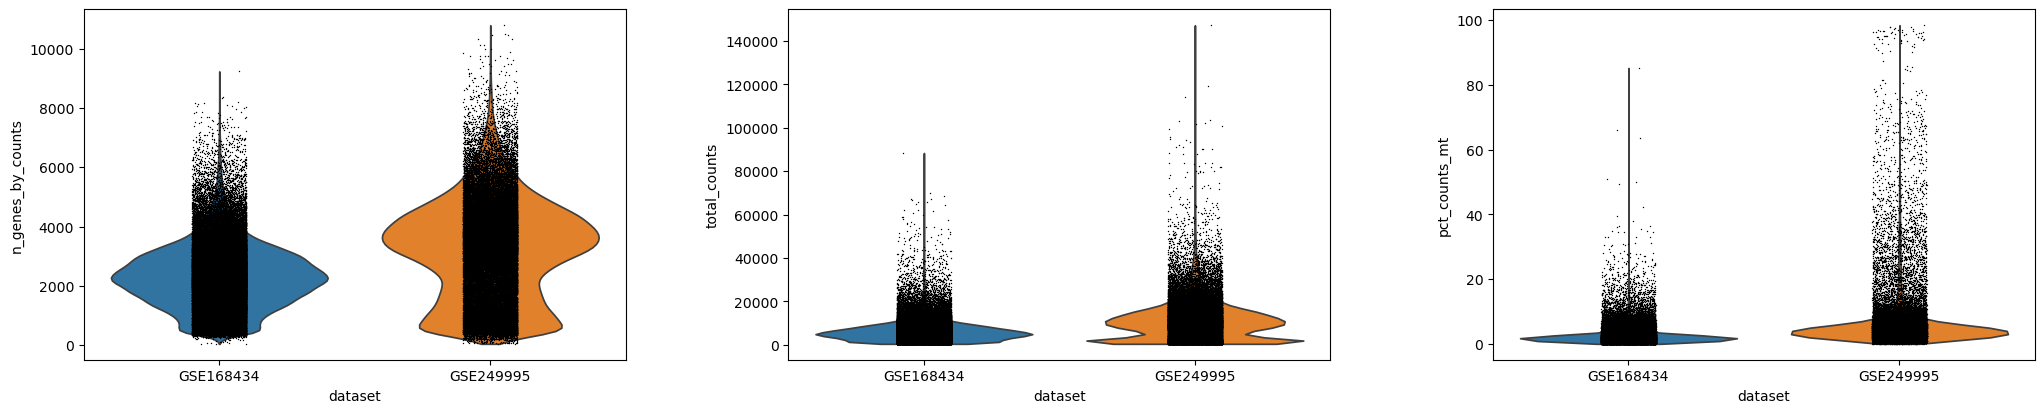

In [41]:
# Visualize QC metrics across datasets
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='dataset', multi_panel=True)

In [42]:
import scrublet as scr

# Define filtering thresholds (Adjust based on violin plots above)
# Standard starting points:
# - keep cells with at least 200 genes
# - keep genes found in at least 3 cells
# - keep cells with < 20% mitochondrial counts (adjust if needed per NBatlas)


# Doublet Detection using Scrublet
# Initialize Scrublet with adata.X (raw counts at this stage) and an expected doublet rate
scrub = scr.Scrublet(adata.X, expected_doublet_rate=0.06) 

# Expected doublet rate based on 10x Genomics guidelines
doublet_scores, predicted_doublets = scrub.scrublet()
adata.obs['doublet_score'] = doublet_scores
adata.obs['predicted_doublet'] = predicted_doublets

print(f"Detected {np.sum(predicted_doublets)} doublets out of {len(adata.obs)} cells.")

AttributeError: 'Scrublet' object has no attribute 'scrublet'

In [31]:
# Define filtering thresholds (Adjust based on violin plots above)
# Standard starting points:
# - keep cells with at least 200 genes
# - keep genes found in at least 3 cells
# - keep cells with < 20% mitochondrial counts (adjust if needed per NBatlas)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [32]:
# Specific threshold for MT
adata = adata[adata.obs.pct_counts_mt < 20, :]

In [33]:
# Log-normalize and identify highly variable genes
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, batch_key='dataset')

/tmp/ipykernel_2202/769345855.py:2: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


In [34]:
# Save processed state
processed_save_path = os.path.join(processed_data_dir, "normalized_filtered_atlas.h5ad")
adata.write(processed_save_path)
print(f"Filtered and normalized data saved to: {processed_save_path}")
print(adata)

Filtered and normalized data saved to: /mnt/h/Projects/scRNA-Seq/RetinoblastomaAtlas/data/processed/normalized_filtered_atlas.h5ad
AnnData object with n_obs × n_vars = 139838 × 36347
    obs: 'sample_id', 'dataset', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'dataset_colors', 'log1p', 'hvg'
